In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer #import for discretization

from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.dropna(inplace=True)

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
x=df.drop(['Survived'],axis=1)
y=df['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2,
                                               random_state=42)

In [7]:
x_train.shape

(571, 2)

In [8]:
y_train.shape

(571,)

In [9]:
clf=DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
accuracy_score(y_test,y_pred)

0.6153846153846154

In [20]:
cross_val_score(clf,x,y,cv=10,scoring='accuracy').mean()

np.float64(0.6345266040688576)

<h1>DISCRETIZATION / BINNING</h1>

In [11]:
kbin_age=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [12]:
trf=ColumnTransformer([('first',kbin_age,[0]),
                      ('second',kbin_fare,[1])])

In [14]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

C:\Users\souha\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\souha\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [15]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [16]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [18]:
clf=DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2=clf.predict(x_test_trf)
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [19]:
x_trf_visual=trf.fit_transform(x)
cross_val_score(clf,x_trf_visual,y,cv=10,scoring='accuracy').mean()

C:\Users\souha\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\souha\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6723004694835681)

<h1>Creating a Binning Function</h1>

In [36]:
def discretize(bins,strategy):
    kbins_age=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbins_fare=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf=ColumnTransformer([('first',kbins_age,[0]),
                          ('second',kbins_fare,[1])])

    x_trf=trf.fit_transform(x)
    print(np.mean(cross_val_score(clf,x_trf,y,cv=10,scoring='accuracy')))

    fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
    ax1.hist(x['Age'])
    ax1.set_title("Before")

    ax2.hist(x_trf[:,0])
    ax2.set_title('After')

    fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
    ax1.hist(x['Fare'])
    ax1.set_title("Before")

    ax2.hist(x_trf[:,1])
    ax2.set_title('After')

C:\Users\souha\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\souha\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.682140062597809


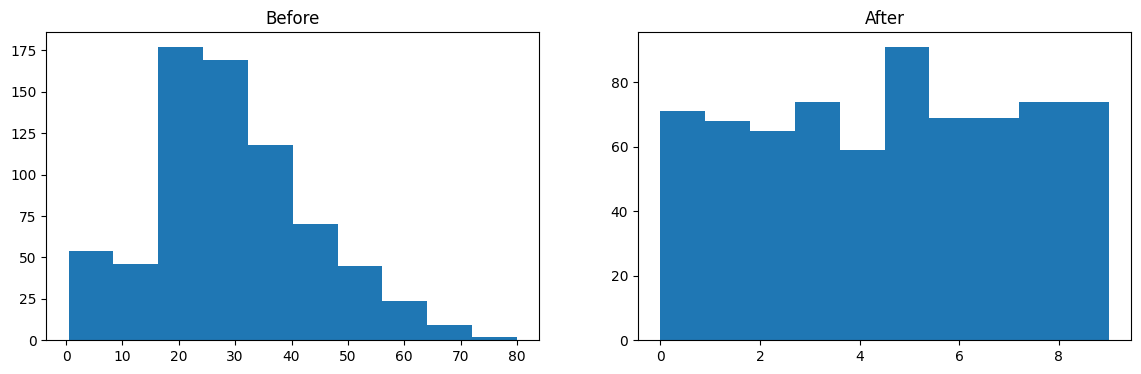

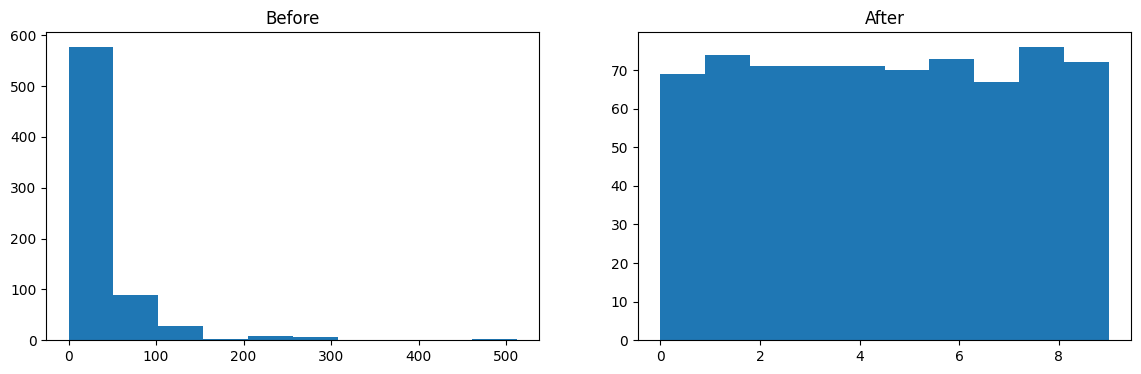

In [37]:
discretize(10,'quantile')

<p>Quantile binning balances sample distribution across bins.</p>

0.6541275430359936


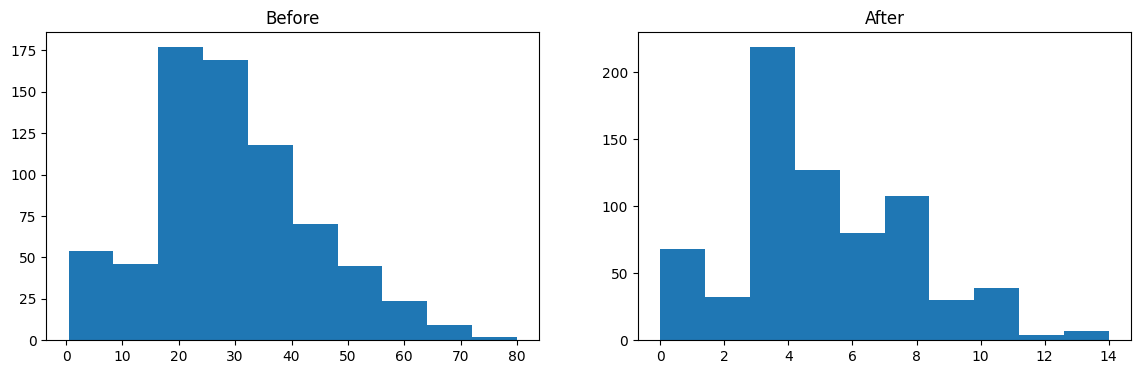

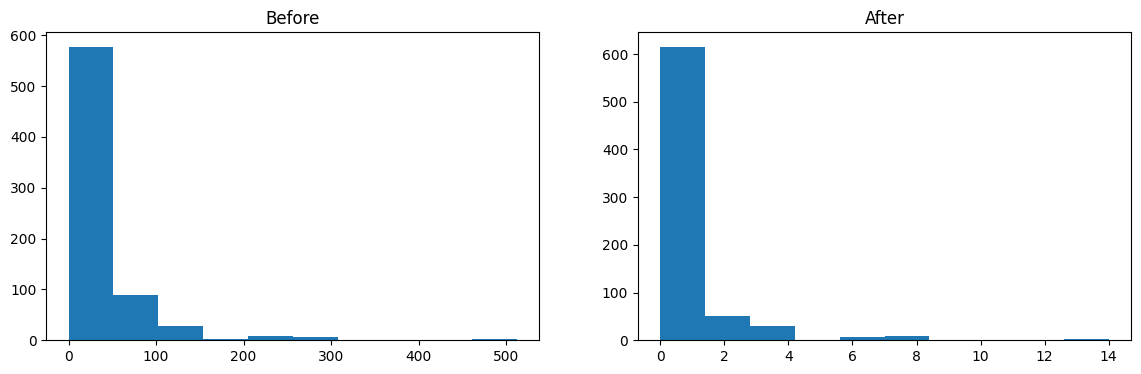

In [38]:
discretize(15,'uniform')

<P>Uniform binning preserves original distribution shape more than quantile binning.</P>

C:\Users\souha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\souha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6723982785602504


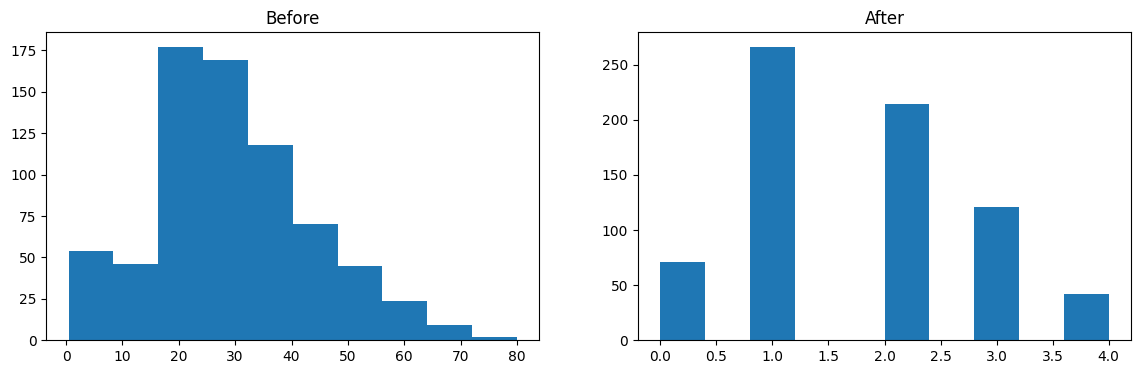

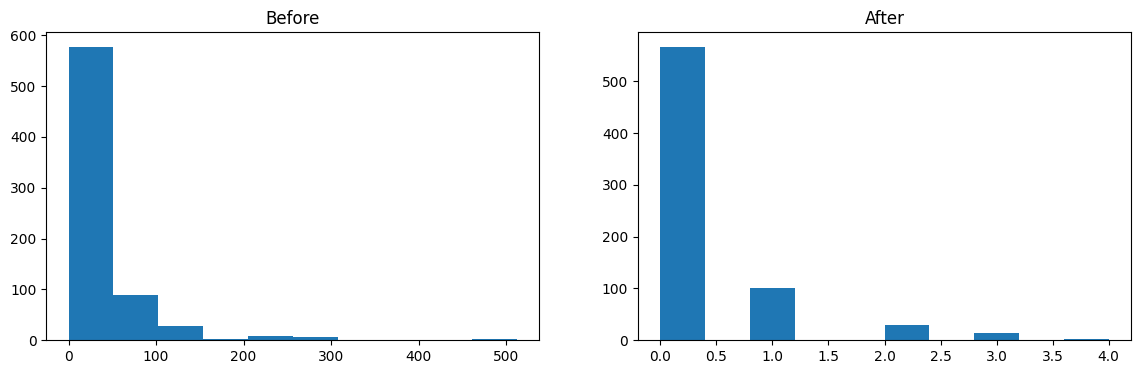

In [39]:
discretize(5,'kmeans')

<p>KMeans discretization adapts to actual data distribution and creates intelligent bins.</p>